# Canvas
### Área donde vamos a proceder a dibujar nuestra visualización. Incluye los ejes, los títulos, las etiquetas de los ejes, la leyenda, etc.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv('tiendas_procesado.csv', index_col='fecha')
df

,DAIRY,MEATS,SEAFOOD
fecha,,,
2015-01,1134521.0,543117.728891,40465.835012
2015-02,1020747.0,498735.076839,36066.561003
2015-03,1234851.0,546517.159221,43808.473074
2015-04,1181180.0,522304.280744,39983.471003
2015-05,1293308.0,591691.899734,42506.832015
2015-06,1243588.0,565014.130035,38780.552004
2015-07,1244815.0,594903.677368,38535.588006
2015-08,1263428.0,581214.143026,37767.580998
2015-09,1224619.0,562711.633157,41906.374010


In [3]:
# Para modificar el tamaño de todas las imágenes que vamos generar usamos este código
# Aplica para las librerías seaborn, pandas y matplotlib al mismo tiempo, lo hace global
plt.rcParams["figure.figsize"] = (15, 3)

<Axes: xlabel='fecha'>

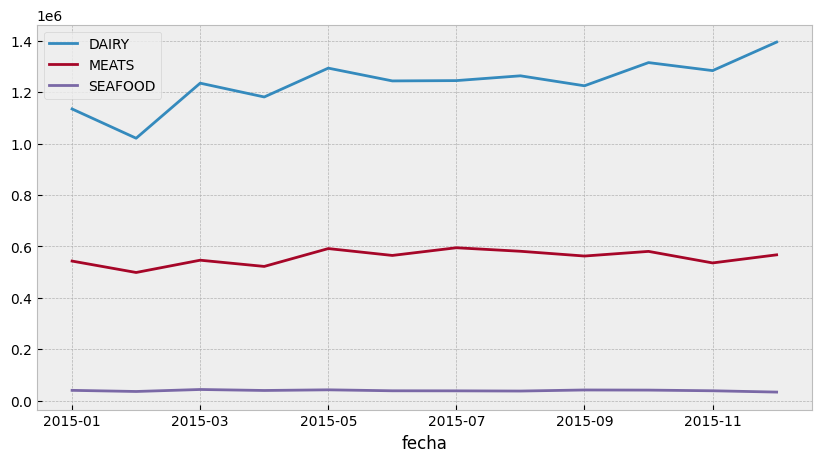

In [4]:
# Estilo de la gráfica
plt.style.use(
    'bmh'
)

df.plot.line(
    figsize=(10,5)
)

<Axes: xlabel='fecha'>

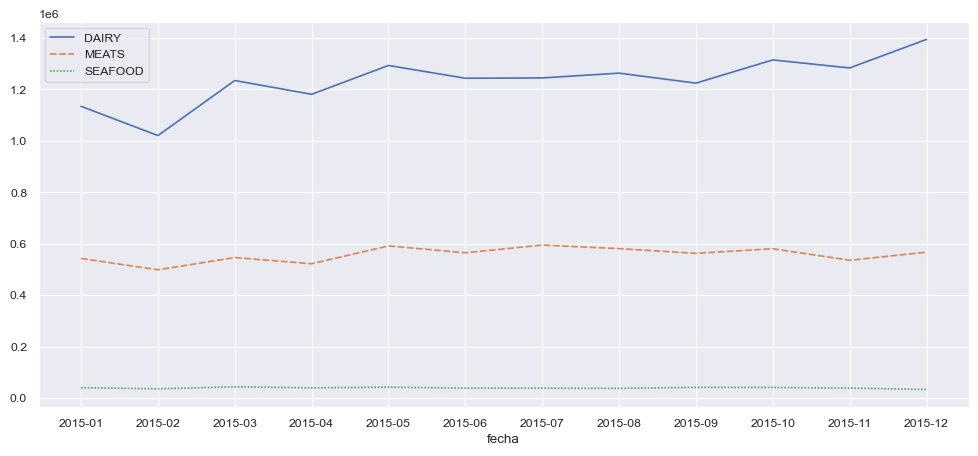

In [25]:
# Este método también es global
plt.figure(
    figsize=(12,5)
)

# Seaborn tiene 4 opciones: dark, white, ticks y whitegrid
sns.set_style('dark')

# Para ser más presentable, que se vea mejor: paper, talk, poster y notebook
sns.set_theme('paper')

sns.lineplot(
    data = df
)

In [6]:
# Configurar plotly
px.line(
    df,
    width=800,
    height=1000,
    template='plotly_dark'
)

# Grid
### Son las líneas que crean la cuadrícula de los gráficos y aprenderemos a personalizarlas

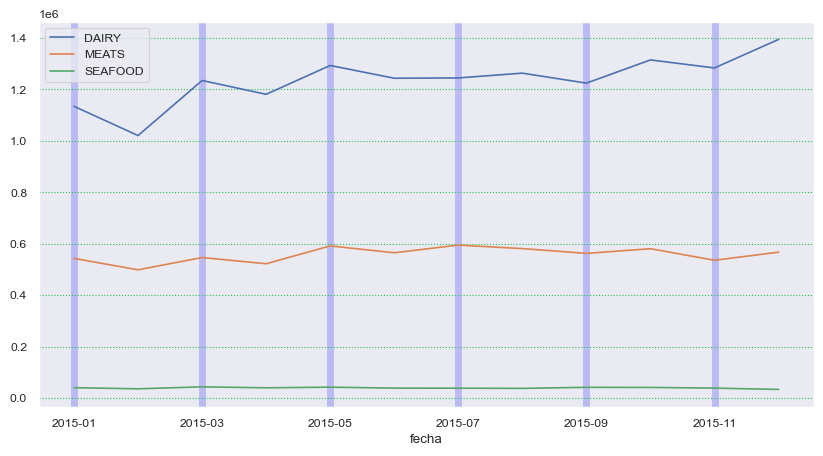

In [12]:
# Personalizar líneas dash (por guiones '-----')
# df.plot.line retorna el grafico y lo podemos almacenar en una variable para personalizarlo, esto solo en matplotlib
ax = df.plot.line(
    figsize=(10,5)
)

ax.xaxis.grid(
    color = 'blue',
    alpha = 0.2,
    linewidth = 5
    # visible = False solo si es el único parámetro y desaparece la cuadrícula del eje x
)

ax.yaxis.grid(
    color = '#28bf50',
    linestyle = 'dotted'
)

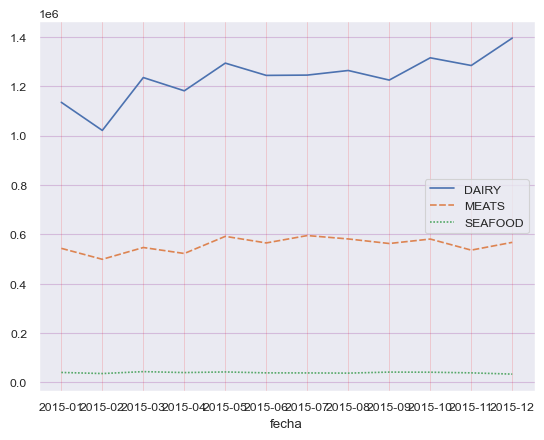

In [14]:
# Ahora en Seaborn
ax = sns.lineplot(
    data = df
)

# Se puede hacer de la misma manera que en matplotlib pero...
ax.xaxis.grid(
    color = 'red',
    alpha = 0.2,
    linewidth = 0.5
)

# Hay una manera más directa con matplotlib, que será un método global como habíamos visto antes
plt.grid(
    axis = 'y',
    color = 'purple',
    alpha = 0.2
)

In [18]:
# Por último con Plotly, aquí se maneja de una manera similar a matplotlib, pero no son iguales y aquí no se aplican los globales de matplotlib
fig = px.line(
    df,
    width = 800,
    height = 500,
    template = 'plotly_dark'
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(
    gridwidth = 1,
    gridcolor = 'white',
    griddash = 'dash',
    minor_griddash = 'dot' # líneas de ayuda entre las principales
)

# Títulos y Ejes
### 1. Título Principal
### 2. Título en los Ejes


Text(0, 0.5, 'Ventas en Millones de Dólares')

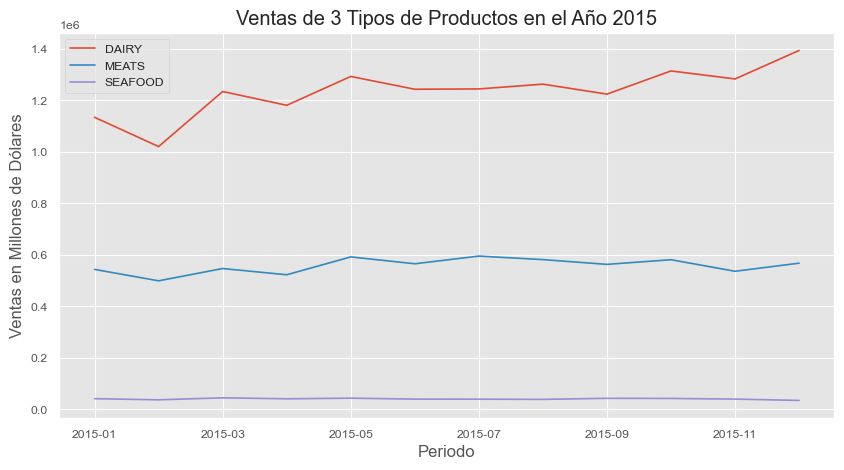

In [21]:
# Matplotlib
plt.style.use(
    'ggplot'
)

ax = df.plot.line(
    figsize = (10,5),
    # Título
    title = 'Ventas de 3 Tipos de Productos en el Año 2015'
)

# Para configurar los títulos de los ejes
ax.set_xlabel(
    'Periodo',
    #loc = 'left', 'center' o 'right'
)

ax.set_ylabel(
    'Ventas en Millones de Dólares',
    #loc = 'bottom', 'center' o 'top'
)

[Text(0.5, 0, 'X label'), Text(0, 0.5, 'Y label'), Text(0.5, 1.0, 'Título')]

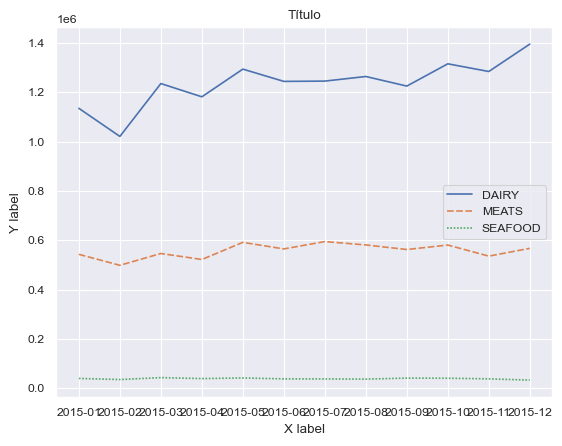

In [26]:
# Seaborn
ax = sns.lineplot( data = df )

# Otro método global es:
plt.title('Ventas de 3 Tipos de Productos en el Año 2015') # Se aplicará para todos los gráficos que vayamos haciendo
plt.xlabel('Periodo')
plt.ylabel('Ventas (En Millones de Dólares)')

ax.set_xlabel('Periodo')

# Otra forma es:
ax.set(
    xlabel = 'X label',
    ylabel = 'Y label',
    title = 'Título'
)

In [28]:
# Plotly
fig = px.line(
    df,
    width = 800,
    height = 500,
    template = 'ggplot2',
    title = 'Ventas de 3 Tipos de Productos en el Año 2015',
    labels = {
        'fecha': 'Periodo',
        'value': 'Ventas En Millones de Dólares',
        # también se modifica desde aquí la leyenda
        'variable': 'Tipo de Producto'
    }
)

# Otra manera:
fig.update_layout(
    xaxis_title = 'PERIODO',
    yaxis_title = 'VENTAS'
)

fig.show() # Para que se pueda mostrar cuando esta en una variable

# Ticks
### Conjunto de etiquetas ubicados en los ejes, sin estos un gráfico es ilegible.

In [4]:
import matplotlib.pyplot as plt
import numpy as np

In [5]:
posiciones_ticks = np.arange(0, len(df))
posiciones_ticks

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

Text(0, 0.5, 'Ventas (en millones de dólares)')

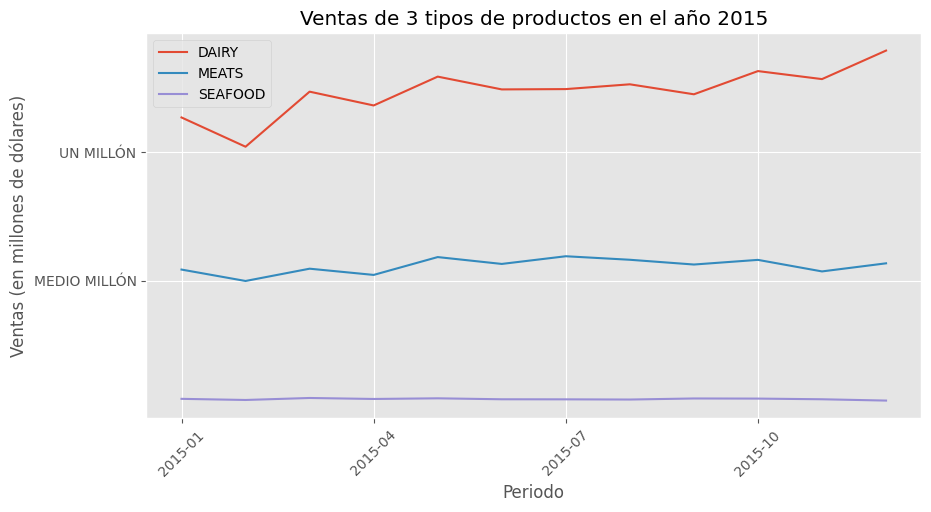

In [ ]:
# Matplot
plt.style.use(
    'ggplot'
)

ax = df.plot.line(
    figsize = (10, 5),
    title = 'Ventas de 3 tipos de productos en el año 2015'
)

# Ticks
ax.set_xticks(
    posiciones_ticks[::3]
)

ax.set_xticklabels(
    df.index.values[::3],
    rotation = 45
)

ax.set_xlabel(
    'Periodo'
)

ax.set_yticks(
    [500000, 1000000]
)

ax.set_yticklabels(
    ['MEDIO MILLÓN', 'UN MILLÓN']
)

ax.set_ylabel(
    'Ventas (en millones de dólares)'
)

[Text(0, 0, 'ENERO'), Text(1, 0, 'FEBRERO')]

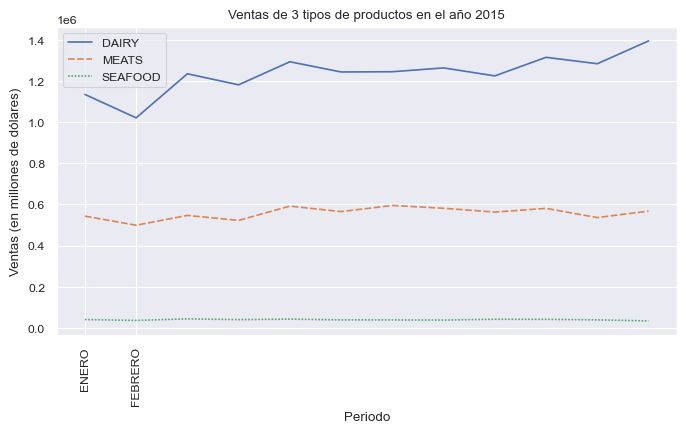

In [ ]:
# Seaborn
plt.figure(
    figsize=(8,4)
)

plt.title('Ventas de 3 tipos de productos en el año 2015')
plt.xlabel('Periodo')
plt.ylabel('Ventas (en millones de dólares)')

sns.set_style("ticks")
sns.set_theme("paper")

ax = sns.lineplot(
    data = df
)

# Ticks
ax.set_xticks([0, 1])
ax.set_xticklabels(['ENERO', 'FEBRERO'], rotation=90)

In [12]:
import plotly.express as px

In [17]:
# Plotly
fig = px.line(
    df, 
    width=800,
    height=400,
    template='ggplot2',
    title='Ventas de 3 tipos de productos por año'
)

fig.update_layout(
    xaxis_title = 'Periodo',
    yaxis_title = 'Ventas en millones de USD'
)

# Ticks
fig.update_xaxes(
    tickangle = 45,
    tickvals = df.index.values,
    tickmode = 'array'
)

fig.update_yaxes(
    #nticks = 8,
    #tickvals = [500000, 1000000],
    dtick = 250000
)

fig.show()

# Estilos de Etiquetas y Texto

### En Matplotlib y Seaborn, se ocupa con las mismas funciones, y el fontdict

Text(0, 0.5, 'Ventas (en millones de dólares)')

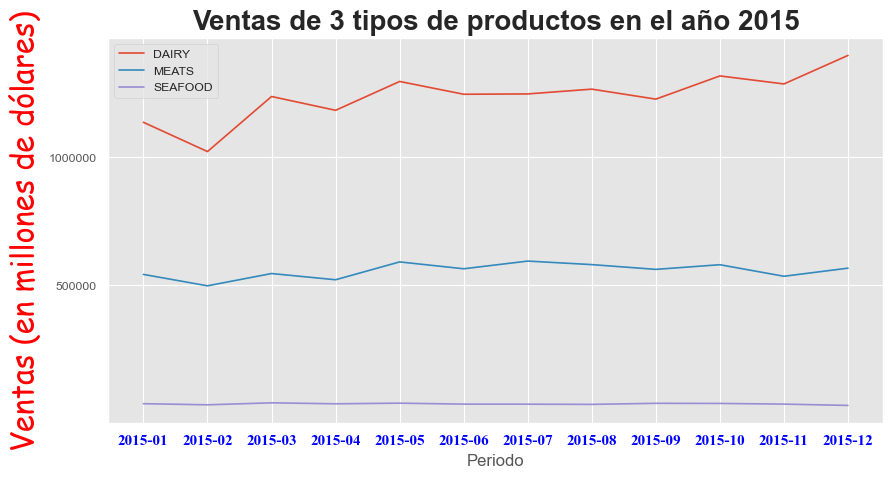

In [ ]:
plt.style.use(
    'ggplot'
)

ax = df.plot.line(
    figsize = (10, 5)
)

# Persolanizar el título principal
ax.set_title(
    'Ventas de 3 tipos de productos en el año 2015',
    fontdict={
        'size' : 20,
        'weight' : 'bold',
    }
)

ax.set_yticks(
    [500000, 1000000]
)

ax.set_yticklabels(
    ['500000', '1000000']
)

ax.set_xticks(np.arange(0, len(df)))
ax.set_xticklabels(
    df.index.values,
    fontdict={
        'color' : 'blue',
        'family': 'Times New Roman',
        'weight' : 'bold',
        'size' : 11
    }   
)

ax.set_xlabel('Periodo')

ax.set_ylabel(
    'Ventas (en millones de dólares)',
    fontdict={
        'name' : 'Comic Sans MS',
        'color': 'red',
        'size' : 22
    }
)

# Así se usa el método global, cuando se ocupan los valores determinados y estos estilos se aplican a todas las gráficas del bloque
plt.yticks(
    color = 'blue',
    name = 'Times New Roman',
)

In [26]:
fig = px.line(
    df, 
    width=800,
    height=500,
    template='ggplot2',
    title='Ventas de 3 tipos de productos por año'
)

# Aquí se define los estilos del texto global
fig.update_layout(
    xaxis_title = 'Periodo',
    yaxis_title = 'Ventas en millones de USD',
    font_color = 'blue',
    font_family = 'Courier New',
    legend_font_color = 'black',
    legend_title_font_color = 'green',
    title_font_color = 'red',
    title_font_family = 'Times New Roman'
)

# Aquí se hacen las modificaciones más específicas 
fig.update_xaxes(
    tickangle = 45,
    tickvals = df.index.values,
    tickmode = 'array',
    title_font_family = 'Arial',
    title_font_color = 'black',
    # Estos son estilos de los ticks
    tickfont = {
        'family' : 'Rockwell',
        'color' : 'brown',
        'size' : 10
    }
)

fig.update_yaxes(
    dtick = 250000
)

fig.show()

# Anotaciones y Marcas

### Recordar que la mayoría si no es que todas las funciones que usamos con Matplotlib, funcionan también de la misma forma en Seaborn, ya que Seaborn, trabaja por detrás con Matplotlib

Text(10, 1000000, 'Noviembre OJO!')

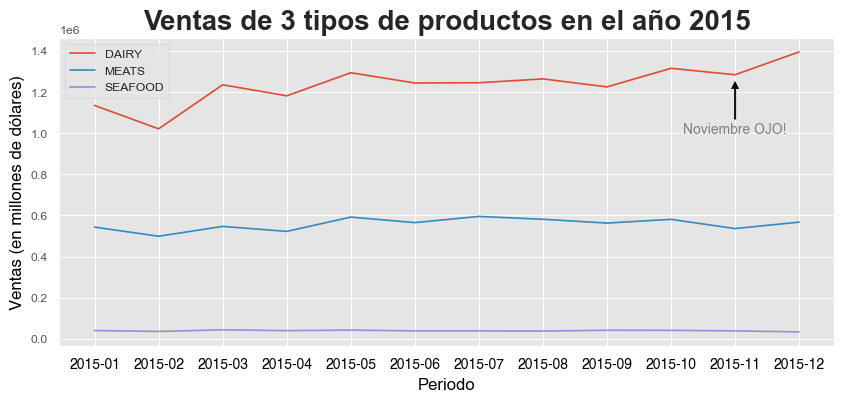

In [31]:
plt.style.use(
    'ggplot'
)

ax = df.plot.line(
    figsize = (10, 4)
)

ax.set_title(
    'Ventas de 3 tipos de productos en el año 2015',
    fontdict={
        'size' : 20,
        'weight' : 'bold',
    }
)

ax.set_xticks(np.arange(0, len(df)))
ax.set_xticklabels(
    df.index.values,
    fontdict={
        'name' : 'Helvetica',
        'color' : 'Black',
        'size' : 10
    }
)

ax.set_xlabel(
    'Periodo',
    fontdict={
        'color' : 'black',
        'size' : 12
    }
)

ax.set_ylabel(
    'Ventas (en millones de dólares)',
    fontdict={
        'name' : 'Helvetica',
        'color' : 'Black',
        'size' : 12
    }
)

ax.annotate(
    'Noviembre OJO!',
    # Posición de la flecha
    xy = (10, 1250000),
    # Posición del texto de la flecha
    xytext = (10, 1000000),
    color = 'gray',
    horizontalalignment = 'center',
    arrowprops={
        'width' : 1,
        'color' : 'black',
        'headwidth' : 5,
        'headlength' : 5
    }
)

Text(11, 1250000, 'Umbral')

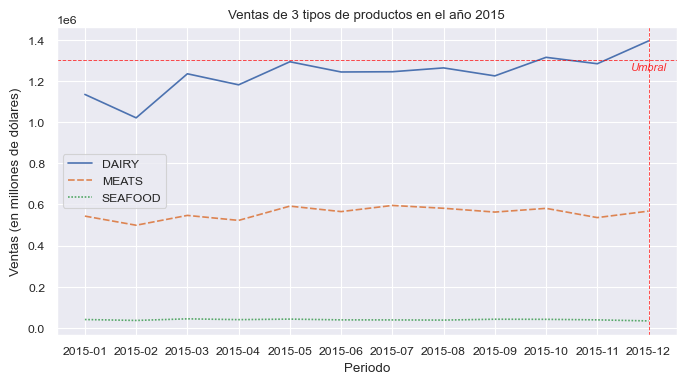

In [ ]:
# Seaborn
plt.figure(
    figsize=(8, 4)
)

plt.title('Ventas de 3 tipos de productos en el año 2015')
plt.xlabel('Periodo')
plt.ylabel('Ventas (en millones de dólares)')

sns.set_style('ticks')
sns.set_theme('paper')

ax = sns.lineplot(
    data = df
)

# Horizontal
ax.axhline(
    1300000,
    linestyle = 'dashed',
    linewidth = 0.7,
    alpha = 0.7,
    color = 'red'
)

# Vertical
ax.axvline(
    11,
    linestyle = 'dashed',
    linewidth = 0.7,
    alpha = 0.7,
    color = 'red'
)

ax.annotate(
    'Umbral',
    xy = (11, 1250000),
    horizontalalignment = 'center',
    color = 'red',
    fontstyle = 'italic',
    alpha = 0.8,
    size = 8
)

In [ ]:
# Plotly
fig = px.line(
    df, 
    width=800,
    height=500,
    template='ggplot2',
    title='Ventas de 3 tipos de productos por año'
)

# Aquí se define los estilos del texto global
fig.update_layout(
    xaxis_title = 'Periodo',
    yaxis_title = 'Ventas en millones de USD',
    font_color = 'blue',
    font_family = 'Courier New',
    legend_font_color = 'black',
    legend_title_font_color = 'green',
    title_font_color = 'red',
    title_font_family = 'Times New Roman'
)

# Aquí se hacen las modificaciones más específicas 
fig.update_xaxes(
    tickangle = 45,
    tickvals = df.index.values,
    tickmode = 'array',
    title_font_family = 'Arial',
    title_font_color = 'black',
    # Estos son estilos de los ticks
    tickfont = {
        'family' : 'Rockwell',
        'color' : 'brown',
        'size' : 10
    }
)

fig.update_yaxes(
    dtick = 250000
)

fig.add_annotation(
    x = '2015-11',
    y = 1300000,
    text='Noviembre',
    opacity = 0.5,
    font = {
        'size' : 10,
        'color' : 'black'
    },
    showarrow = True,
    arrowsize = 1,
    arrowwidth = 2, 
    arrowhead = 2 # 0 al 8, que indica el tipo de la flecha
)

# Aquí se agregan las anotaciones directamente en la función
fig.add_hline(
    y = 1300000,
    annotation_text = 'Límite',
    annotation_position = 'top left',
    annotation_font_color = 'red',
    annotation_font_size = 10,
    line_dash = 'dot',
    opacity = 0.8,
    line_width = 1,
    line_color = 'red'
)

fig.show()

# Leyendas

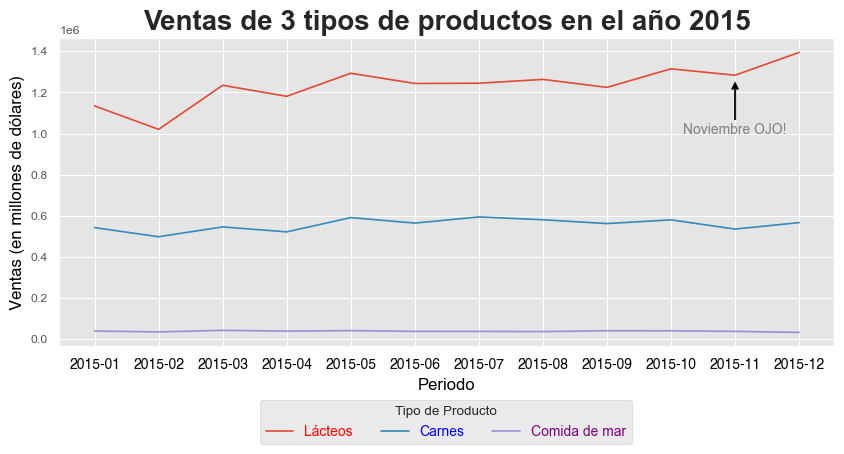

In [55]:
plt.style.use(
    'ggplot'
)

ax = df.plot.line(
    figsize = (10, 4)
)

ax.set_title(
    'Ventas de 3 tipos de productos en el año 2015',
    fontdict={
        'size' : 20,
        'weight' : 'bold',
    }
)

ax.set_xticks(np.arange(0, len(df)))
ax.set_xticklabels(
    df.index.values,
    fontdict={
        'name' : 'Helvetica',
        'color' : 'Black',
        'size' : 10
    }
)

ax.set_xlabel(
    'Periodo',
    fontdict={
        'color' : 'black',
        'size' : 12
    }
)

ax.set_ylabel(
    'Ventas (en millones de dólares)',
    fontdict={
        'name' : 'Helvetica',
        'color' : 'Black',
        'size' : 12
    }
)

ax.annotate(
    'Noviembre OJO!',
    xy = (10, 1250000),
    xytext = (10, 1000000),
    color = 'gray',
    horizontalalignment = 'center',
    arrowprops={
        'width' : 1,
        'color' : 'black',
        'headwidth' : 5,
        'headlength' : 5
    }
)

# Leyenda
ax.legend(
    title = 'Tipo de Producto',
    labels = ['Lácteos', 'Carnes', 'Comida de mar'],
    fontsize = 10,
    loc = 'upper left',
    bbox_to_anchor = (0.25, -0.15), # Puede ser decimal o pasarse del 100% (0.5, 0.5) o (1.5, 1.1)
    labelcolor = ['red', 'blue', 'purple'],
    ncol = 3 # Los pone en columnas
)

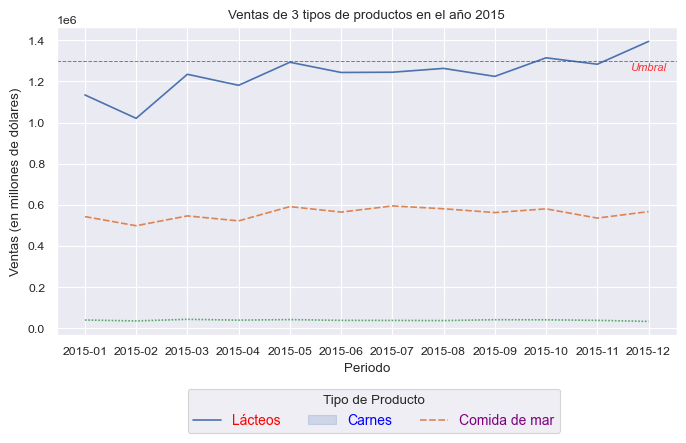

In [ ]:
# Seaborn
plt.figure(
    figsize=(8, 4)
)

plt.title('Ventas de 3 tipos de productos en el año 2015')
plt.xlabel('Periodo')
plt.ylabel('Ventas (en millones de dólares)')

sns.set_style('ticks')
sns.set_theme('paper')

ax = sns.lineplot(
    data = df
)

ax.axhline(
    1300000,
    linestyle = 'dashed',
    linewidth = 0.7,
    alpha = 0.7,
    color = 'red'
)

ax.annotate(
    'Umbral',
    xy = (11, 1250000),
    horizontalalignment = 'center',
    color = 'red',
    fontstyle = 'italic',
    alpha = 0.8,
    size = 8
)

# Leyenda Oculta
ax.legend().set_visible(False)

In [59]:
# Plotly
fig = px.line(
    df, 
    width=800,
    height=500,
    template='ggplot2',
    title='Ventas de 3 tipos de productos por año'
)

fig.update_layout(
    xaxis_title = 'Periodo',
    yaxis_title = 'Ventas en millones de USD',
    font_color = 'blue',
    font_family = 'Courier New',
    legend_font_color = 'black',
    legend_title_font_color = 'green',
    title_font_color = 'red',
    title_font_family = 'Times New Roman'
)

fig.update_xaxes(
    tickangle = 45,
    tickvals = df.index.values,
    tickmode = 'array',
    title_font_family = 'Arial',
    title_font_color = 'black',
    tickfont = {
        'family' : 'Rockwell',
        'color' : 'brown',
        'size' : 10
    }
)

fig.update_yaxes(
    dtick = 250000
)

fig.add_annotation(
    x = '2015-11',
    y = 1300000,
    text='Noviembre',
    opacity = 0.5,
    font = {
        'size' : 10,
        'color' : 'black'
    },
    showarrow = True,
    arrowsize = 1,
    arrowwidth = 2, 
    arrowhead = 2
)

fig.add_hline(
    y = 1300000,
    annotation_text = 'Límite',
    annotation_position = 'top left',
    annotation_font_color = 'red',
    annotation_font_size = 10,
    line_dash = 'dot',
    opacity = 0.8,
    line_width = 1,
    line_color = 'red'
)

# Leyenda
fig.update_layout(
    legend_title_text = 'Leyenda',
    legend = {
        'y': 0.5,
        'x': 1.05,
        'font' : {
            'family': 'Courier',
            'size': 12,
            'color': 'green'
        },
        'bgcolor' : 'LightGray',
        'bordercolor': 'black',
        'borderwidth': 2
    }
)

fig.show()

# Subgráfico

### Mostrar varios gráficos y se utilizan por separado, en una cuadrículo

In [60]:
import matplotlib.pyplot as plt

(<Figure size 640x480 with 15 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

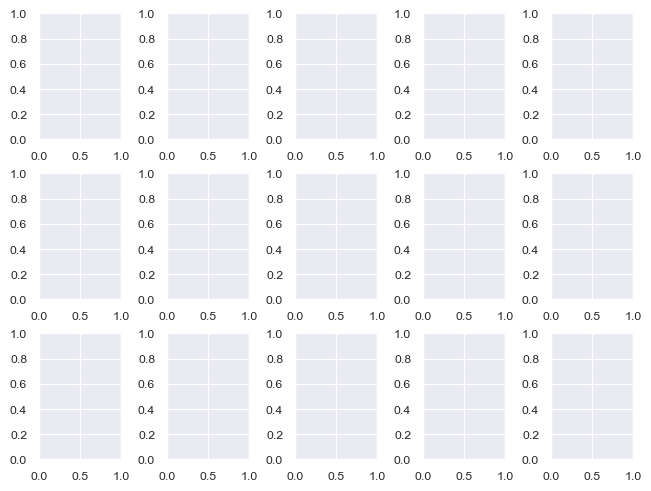

In [ ]:
plt.subplots(3, 5, constrained_layout = True) # Filas y Columnas, constrainded_layout para que tengan una buena separación

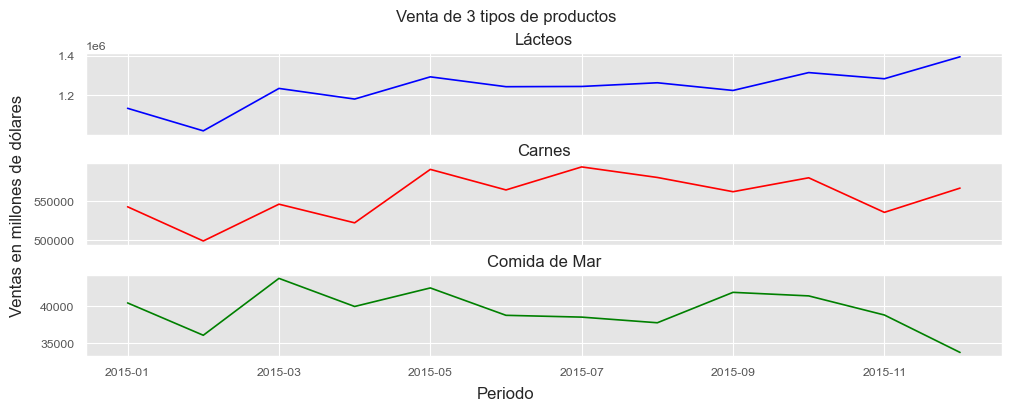

In [73]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, constrained_layout = True)

fig.suptitle('Venta de 3 tipos de productos')
fig.supylabel('Ventas en millones de dólares')
fig.supxlabel('Periodo')

fig.set_size_inches(8, 6)

plt.style.use(
    'ggplot'
)

df.plot.line(
    figsize = (10, 4),
    y = 'DAIRY',
    ax = ax1,
    color = 'blue'
)

df.plot.line(
    figsize = (10, 4),
    y = 'MEATS',
    ax = ax2,
    color = 'red'
)

df.plot.line(
    figsize = (10, 4),
    y = 'SEAFOOD',
    ax = ax3,
    color = 'green'
)

# Quitar los ticks en las dos primeras gráficas
ax1.set_xticklabels([])
ax2.set_xticklabels([])

# Quitar los labels para poner un título global
ax1.set_xlabel('')
ax2.set_xlabel('')
ax3.set_xlabel('')

# Poner título a cada gráfica
ax1.set_title('Lácteos', fontdict={'size' : 12})
ax2.set_title('Carnes', fontdict={'size' : 12})
ax3.set_title('Comida de Mar', fontdict={'size' : 12})

ax1.legend().set_visible(False)
ax2.legend().set_visible(False)
ax3.legend().set_visible(False)

/var/folders/yt/dgxp3gbd7yv1jdkkkd5g2sfw0000gn/T/ipykernel_33627/452269989.py:35: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



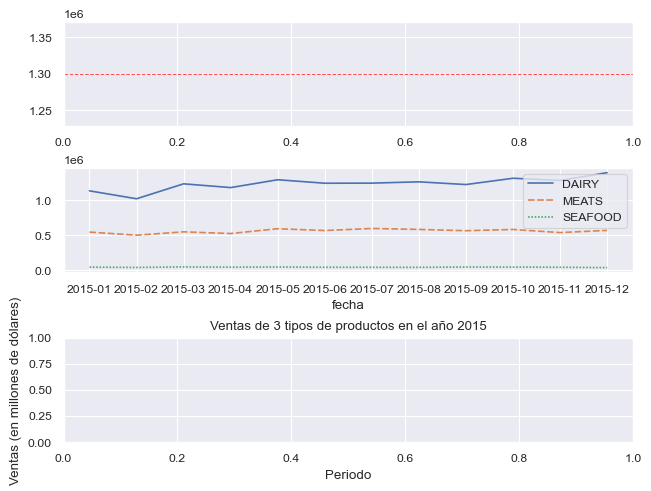

In [ ]:
# Seaborn
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, constrained_layout = True)

# Al utilizar otras gráficas, estos titulos globales no se establecen bien
plt.title('Ventas de 3 tipos de productos en el año 2015')
plt.xlabel('Periodo')
plt.ylabel('Ventas (en millones de dólares)')

sns.set_style('ticks')
sns.set_theme('paper')

sns.lineplot(
    data = df,
    ax = ax2
)

ax1.axhline(
    1300000,
    linestyle = 'dashed',
    linewidth = 0.7,
    alpha = 0.7,
    color = 'red'
)

ax1.annotate(
    'Umbral',
    xy = (11, 1250000),
    horizontalalignment = 'center',
    color = 'red',
    fontstyle = 'italic',
    alpha = 0.8,
    size = 8
)

# Leyenda Oculta
ax1.legend().set_visible(False)

### Con plotly.express no se pueden hacer las subgráficas, se necesita otra parte de plotly para poder realizar esto

In [77]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [80]:
fig = make_subplots(rows = 3, cols = 1)

fig.append_trace(
    go.Scatter(
        x = df.index.values,
        y = df['DAIRY'],
        name = 'LACTEOS'
    ), row = 1, col = 1
)

fig.append_trace(
    go.Scatter(
        x = df.index.values,
        y = df['MEATS'],
        name = 'CARNES'
    ), row = 2, col = 1
)

fig.append_trace(
    go.Scatter(
        x = df.index.values,
        y = df['SEAFOOD'],
        name = 'COMIDA DE MAR'
    ), row = 3, col = 1
)

fig.update_layout(
    height = 600,
    width = 700,
    title_text = 'VENTAS DE 3 TIPOS DE PRODUCTOS'
)

fig.show()

# Guardado

### Guardar los gráficos en formatos de imagen, PNG, JPG, SVG

## Con Plotly para guardar, cuando se genera la gráfica, esta tiene un ícono de cámara en el que le puedes dar para que se descargue la imagen y guardarla, sin embargo, esta pierde las propiedades interactivas que tiene la gráfica por defecto

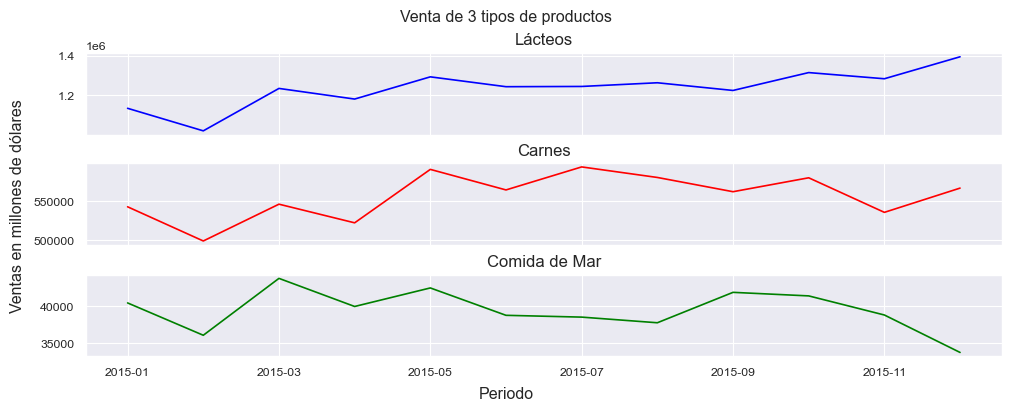

In [84]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, constrained_layout = True)

fig.suptitle('Venta de 3 tipos de productos')
fig.supylabel('Ventas en millones de dólares')
fig.supxlabel('Periodo')

fig.set_size_inches(8, 6)

plt.style.use(
    'ggplot'
)

df.plot.line(
    figsize = (10, 4),
    y = 'DAIRY',
    ax = ax1,
    color = 'blue'
)

df.plot.line(
    figsize = (10, 4),
    y = 'MEATS',
    ax = ax2,
    color = 'red'
)

df.plot.line(
    figsize = (10, 4),
    y = 'SEAFOOD',
    ax = ax3,
    color = 'green'
)

ax1.set_xticklabels([])
ax2.set_xticklabels([])

ax1.set_xlabel('')
ax2.set_xlabel('')
ax3.set_xlabel('')

ax1.set_title('Lácteos', fontdict={'size' : 12})
ax2.set_title('Carnes', fontdict={'size' : 12})
ax3.set_title('Comida de Mar', fontdict={'size' : 12})

ax1.legend().set_visible(False)
ax2.legend().set_visible(False)
ax3.legend().set_visible(False)

# Guardar las imágenes
plt.savefig(
    './pruebaMatplot.png',
    format = 'png',
    dpi = 1200 # La calidad de la imagen, mientras más alto el valor, mejor la calidad
)

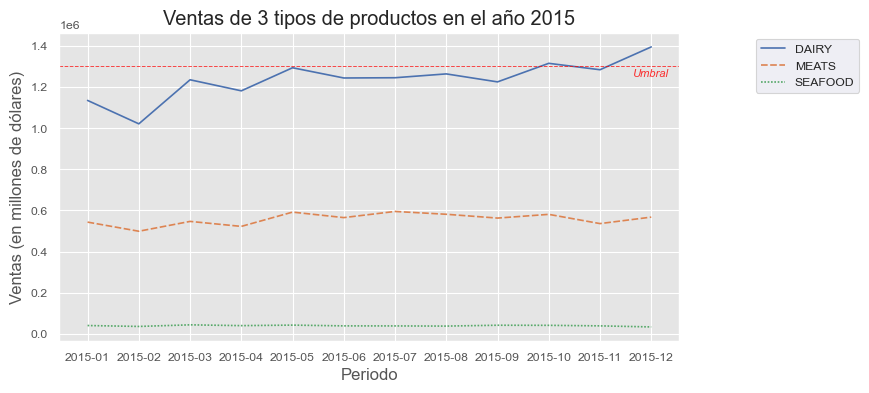

In [85]:
# Seaborn
plt.figure(
    figsize=(8, 4)
)

plt.title('Ventas de 3 tipos de productos en el año 2015')
plt.xlabel('Periodo')
plt.ylabel('Ventas (en millones de dólares)')

sns.set_style('ticks')
sns.set_theme('paper')

ax = sns.lineplot(
    data = df
)

ax.axhline(
    1300000,
    linestyle = 'dashed',
    linewidth = 0.7,
    alpha = 0.7,
    color = 'red'
)

ax.annotate(
    'Umbral',
    xy = (11, 1250000),
    horizontalalignment = 'center',
    color = 'red',
    fontstyle = 'italic',
    alpha = 0.8,
    size = 8
)

ax.legend(bbox_to_anchor = (1.3, 1))

plt.savefig(
    './pruebaSeaborn.png',
    format = 'png',
    dpi = 300,
    bbox_inches = 'tight' # Hace que si nos pasamos del 100% en la leyenda, aún así esta si se incluya en la imagen y no la recorte
)